# BioOptima — Report figures for Chapter 4 (Colab)

All plots for `MAJOR_PROJECT_REPORT.md` §4.3–4.7 — **display only** (screenshot in Colab, no download folder).

**Colab (important):**
1. Upload `webapp` to Drive (`src/`, `data/generated/`, `data/validation/`).
2. **Runtime → Run all** — run cells **in order** (mount → **copy to local** → pip → imports).
3. Screenshot each figure for your report.

**If `import shap` fails with `Errno 107 Transport endpoint is not connected`:**
Your project was on a disconnected Drive mount. Re-run from cell 1; the **copy-to-local** cell fixes this.

**Local:** open from project root; skip mount/copy cells.


In [1]:
# Colab only — skip when running locally
import os
import sys

try:
    from google.colab import drive
except ImportError:
    print("Not Colab — skip this cell.")
else:
    drive.mount("/content/drive")
    MY_DRIVE = "/content/drive/MyDrive"
    PROJECT_ROOT = ""  # e.g. "/content/drive/MyDrive/major_project/webapp"

    def _is_root(p):
        return os.path.isdir(p) and os.path.isdir(os.path.join(p, "src"))

    if not PROJECT_ROOT or not _is_root(PROJECT_ROOT):
        from collections import deque
        found, q = None, deque([(MY_DRIVE, 0)])
        while q and not found:
            p, d = q.popleft()
            if d > 5:
                continue
            if _is_root(p):
                found = p
                break
            if os.path.isdir(p):
                for name in os.listdir(p):
                    c = os.path.join(p, name)
                    if not name.startswith(".") and os.path.isdir(c):
                        q.append((c, d + 1))
        if not found:
            raise FileNotFoundError("Set PROJECT_ROOT to your Drive folder containing src/")
        PROJECT_ROOT = found
        print("Auto-detected:", PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    print("OK — Drive project:", os.getcwd())


Not Colab — skip this cell.


In [2]:
# Copy project to Colab local disk — avoids "Transport endpoint is not connected" (Errno 107)
import os
import shutil
import sys

try:
    import google.colab  # noqa: F401
except ImportError:
    print("Not Colab — skip (run from project root locally).")
else:
    DRIVE_ROOT = os.getcwd()
    LOCAL = "/content/biooptima"
    if os.path.abspath(DRIVE_ROOT) != os.path.abspath(LOCAL):
        if os.path.isdir(LOCAL):
            shutil.rmtree(LOCAL, ignore_errors=True)
        print("Copying to local disk (one-time, may take 1–3 min)...")
        shutil.copytree(
            DRIVE_ROOT,
            LOCAL,
            dirs_exist_ok=True,
            ignore=shutil.ignore_patterns(".git", "__pycache__", ".venv", "node_modules", ".ipynb_checkpoints"),
        )
        os.chdir(LOCAL)
        sys.path.insert(0, LOCAL)
    print("Working directory:", os.getcwd())


Not Colab — skip (run from project root locally).


In [3]:
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    import subprocess
    import sys
    pkgs = [
        "xgboost>=2.0,<4", "shap>=0.43,<1", "imbalanced-learn>=0.12,<0.14",
        "seaborn>=0.13,<1", "scikit-learn>=1.3,<1.6", "joblib>=1.3,<2", "PyYAML>=6,<7",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])
    print("Installed. If imports fail: Runtime → Restart session → Run all.")
else:
    print("Local env — pip skipped.")


Local env — pip skipped.


In [4]:
import json, sys, time, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    mean_squared_error, r2_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor

ROOT = Path.cwd()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as feat_mod
from src import health_utils, simulator

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

SEED = 42
V_LIQ = 100.0
CSV_PATH = ROOT / "data" / "generated" / "biogas_training_merged.csv"

READABLE = {
    "cow_frac": "Cow dung fraction", "rice_frac": "Rice straw fraction",
    "wheat_frac": "Wheat straw fraction", "food_frac": "Food waste fraction",
    "press_frac": "Press mud fraction", "poultry_frac": "Poultry litter fraction",
    "temperature_C": "Temperature (C)", "HRT_days": "HRT (days)",
    "OLR": "Organic loading rate", "CN_ratio": "Blended C/N ratio",
    "VS_total": "Total VS loaded", "temp_HRT": "Temperature x HRT",
    "lipid_frac_mix": "Lipid fraction", "protein_frac_mix": "Protein fraction",
    "COD_proxy": "COD proxy", "OLR_x_food_frac": "OLR x food fraction",
    "protein_to_CN": "Protein / C:N", "OLR_per_HRT": "OLR / HRT",
    "lipid_x_temp": "Lipid x Temperature",
}

print("Project root:", ROOT)
print("Plots display inline only — screenshot each figure for your report (no files saved).")


Project root: d:\major project\webapp
Plots display inline only — screenshot each figure for your report (no files saved).


In [5]:
for name, p in [
    ("Training CSV", CSV_PATH),
    ("Literature CSV", ROOT / "data" / "validation" / "literature_points.csv"),
]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {name}: {p}")
    print("OK", name)


OK Training CSV
OK Literature CSV


---
## Train / load models (required for §4.3–4.6)


In [6]:
df = pd.read_csv(CSV_PATH)
if "OLR" not in df.columns and "OLR_used" in df.columns:
    df["OLR"] = df["OLR_used"]
df = df[(df["converged"] == True) & (df["stability_label"] >= 0)].copy()
X_df = feat_mod.dataframe_features(df)
X = X_df.values
y_yield = df["q_ch4_avg"].astype(float).values
y_health = df["stability_label"].astype(int).values

try:
    X_train, X_test, y_tr, y_te, h_tr, h_te = train_test_split(
        X, y_yield, y_health, test_size=0.15, random_state=SEED, stratify=y_health)
except ValueError:
    X_train, X_test, y_tr, y_te, h_tr, h_te = train_test_split(
        X, y_yield, y_health, test_size=0.15, random_state=SEED)

reg = XGBRegressor(
    n_estimators=400, learning_rate=0.06, max_depth=6,
    subsample=0.85, colsample_bytree=0.85, random_state=SEED, n_jobs=-1)
reg.fit(X_train, y_tr)
pred = reg.predict(X_test)
yield_r2 = r2_score(y_te, pred)
yield_rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
print(f"Rows: {len(df)} | Hold-out R2={yield_r2:.4f} RMSE={yield_rmse:.2f} m3/d")


Rows: 4700 | Hold-out R2=0.9981 RMSE=1.03 m3/d


---
## §4.3 Yield model performance


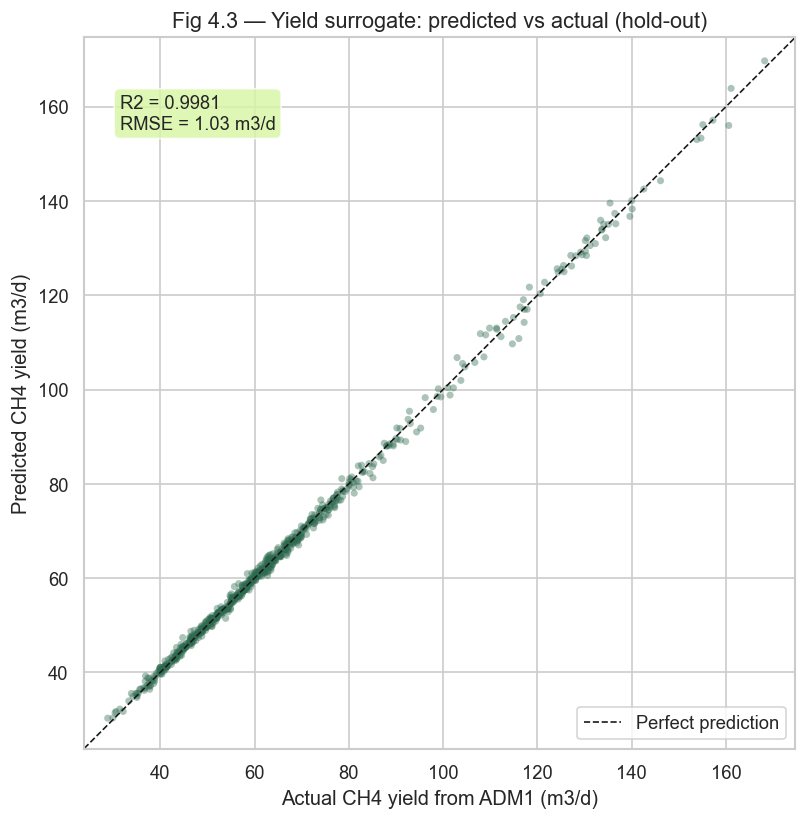

In [7]:
# --- Report 4.3: Yield scatter (predicted vs ADM1 q_ch4_avg) ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, pred, alpha=0.4, s=18, color="#2d6a4f", edgecolors="none")
lims = [min(y_te.min(), pred.min()) - 5, max(y_te.max(), pred.max()) + 5]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual CH4 yield from ADM1 (m3/d)", fontsize=12)
ax.set_ylabel("Predicted CH4 yield (m3/d)", fontsize=12)
ax.set_title("Fig 4.3 — Yield surrogate: predicted vs actual (hold-out)", fontsize=13)
ax.text(0.05, 0.92, f"R2 = {yield_r2:.4f}\nRMSE = {yield_rmse:.2f} m3/d",
        transform=ax.transAxes, fontsize=11, va="top",
        bbox=dict(boxstyle="round", facecolor="#d8f5a2", alpha=0.8))
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


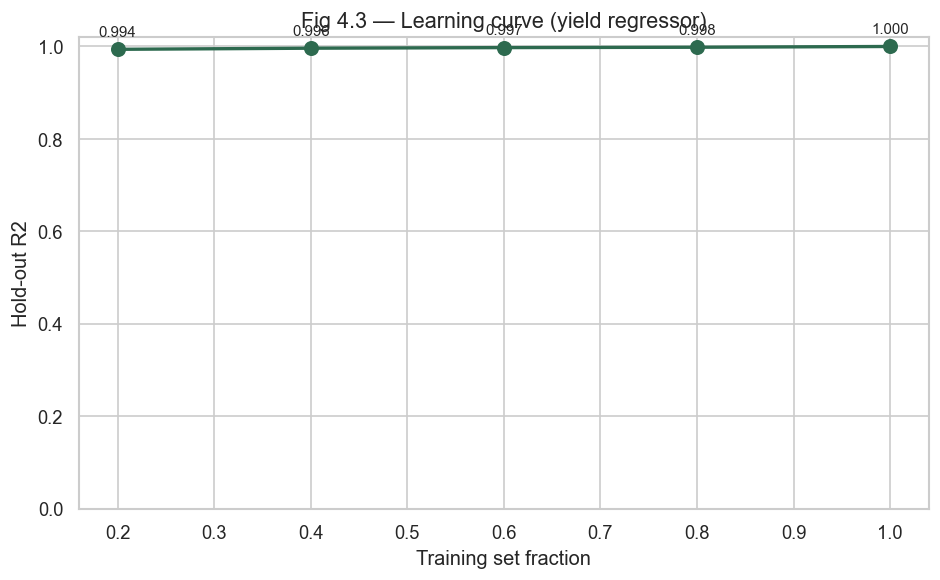

In [8]:
# --- Report 4.3: Learning curve ---
em_path = ROOT / "models" / "eval_metrics.json"
lc = None
if em_path.is_file():
    lc = json.loads(em_path.read_text(encoding="utf-8")).get("learning_curve")

if not lc:
    print("Computing learning curve (or upload models/eval_metrics.json from train_models.py)...")
    fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
    lc = []
    n = len(X)
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(n)
    for f in fracs:
        n_use = max(30, int(n * f))
        tr_idx = idx[:n_use]
        te_idx = idx[int(n * 0.85):]
        m = XGBRegressor(n_estimators=400, learning_rate=0.06, max_depth=6, random_state=SEED, n_jobs=-1)
        m.fit(X[tr_idx], y_yield[tr_idx])
        lc.append({"fraction": f, "n_train": n_use, "r2": float(r2_score(y_yield[te_idx], m.predict(X[te_idx])))})

fracs = [row["fraction"] for row in lc]
r2s = [row["r2"] for row in lc]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fracs, r2s, "o-", color="#2d6a4f", linewidth=2, markersize=8)
ax.set_xlabel("Training set fraction", fontsize=12)
ax.set_ylabel("Hold-out R2", fontsize=12)
ax.set_title("Fig 4.3 — Learning curve (yield regressor)", fontsize=13)
ax.set_ylim(0, 1.02)
for x, y, n in zip(fracs, r2s, [row.get("n_train", "") for row in lc]):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


---
## §4.4 Health classifier performance


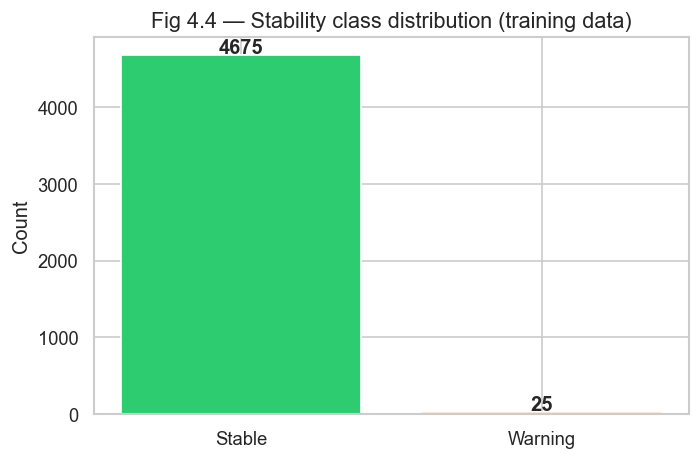

In [12]:
# --- Report 4.4: Class distribution ---
counts = df["stability_label"].value_counts().sort_index()
labels_map = {0: "Stable", 1: "Warning", 2: "Critical"}
colors = ["#2ecc71", "#e67e22", "#e74c3c"]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [labels_map.get(int(k), str(k)) for k in counts.index],
    counts.values,
    color=[colors[min(int(k), 2)] for k in counts.index],
    edgecolor="white",
)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, str(v),
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Count")
ax.set_title("Fig 4.4 — Stability class distribution (training data)", fontsize=13)
plt.tight_layout()
plt.show()


Hold-out macro F1 = 0.9441


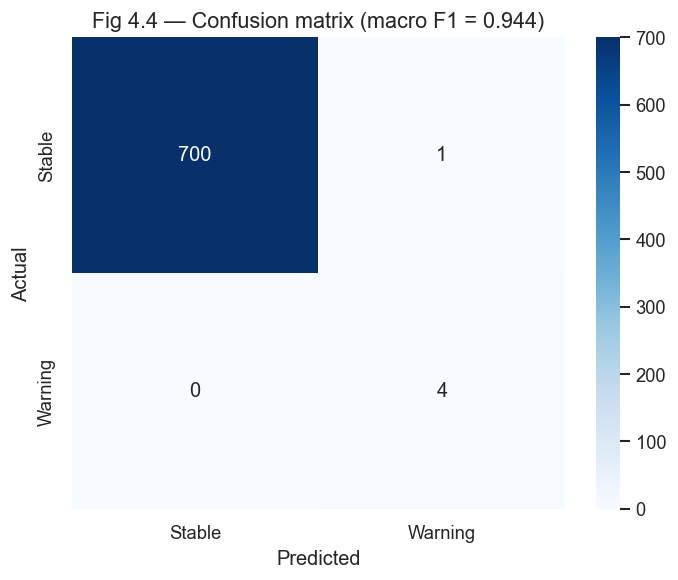

In [14]:
# --- Report 4.4: Confusion matrix ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

clf_base = XGBClassifier(
    n_estimators=300, learning_rate=0.08, max_depth=5, subsample=0.9,
    colsample_bytree=0.85, random_state=SEED, n_jobs=-1,
    objective="multi:softprob", num_class=3, eval_metric="mlogloss"
)

kn = min(3, int(np.bincount(h_tr).min()) - 1) if len(np.unique(h_tr)) > 1 else 0
if kn >= 1:
    clf_pipe = ImbPipeline([("smote", SMOTE(random_state=SEED, k_neighbors=kn)), ("clf", clf_base)])
    clf_pipe.fit(X_train, h_tr)
    hp = np.asarray(clf_pipe.predict(X_test))
else:
    clf_base.fit(X_train, h_tr)
    hp = np.asarray(clf_base.predict(X_test))

# robust conversion for different sklearn/xgboost outputs
if hp.ndim == 2:
    if hp.shape[1] == 1:
        hp = (hp[:, 0] >= 0.5).astype(int)
    else:
        hp = np.argmax(hp, axis=1)

hp = np.asarray(hp).astype(int).ravel()
h_te_arr = np.asarray(h_te).astype(int).ravel()

all_labels = sorted(np.unique(np.concatenate([h_te_arr, hp])))
target_names = [{0: "Stable", 1: "Warning", 2: "Critical"}.get(l, f"C{l}") for l in all_labels]

health_f1 = f1_score(h_te_arr, hp, average="macro", labels=all_labels, zero_division=0)
print(f"Hold-out macro F1 = {health_f1:.4f}")

cm = confusion_matrix(h_te_arr, hp, labels=all_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=target_names, yticklabels=target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Fig 4.4 — Confusion matrix (macro F1 = {health_f1:.3f})", fontsize=13)
plt.tight_layout()
plt.show()

---
## §4.5 SHAP analysis

Run the import cell first, then the two plots.


In [ ]:
# Import SHAP only here (after local copy + pip) — not in the main imports cell
try:
    import shap  # noqa: F401
    from src.shap_viz import plot_beeswarm, plot_waterfall
    _SHAP_OK = True
    print("SHAP ready.")
except OSError as exc:
    _SHAP_OK = False
    print("SHAP import failed:", exc)
    print("→ Runtime → Restart session, then Run all from the top (mount + copy-to-local cells).")
except ImportError as exc:
    _SHAP_OK = False
    print("SHAP not installed:", exc)
    print("→ Re-run the pip install cell, restart runtime, Run all.")


In [ ]:
# --- Report 4.5: SHAP beeswarm ---
if not _SHAP_OK:
    print("Skipped — fix SHAP import in the cell above.")
else:
    bg_sample = pd.DataFrame(X_test[:200], columns=feat_mod.FEATURE_COLUMNS)
    fig = plot_beeswarm(reg, bg_sample)
    fig.suptitle("Fig 4.5 — SHAP beeswarm (methane yield model)", fontsize=13, y=0.98)
    plt.tight_layout()
    plt.show()


In [ ]:
# --- Report 4.5: SHAP waterfall (representative co-digestion point) ---
if not _SHAP_OK:
    print("Skipped — fix SHAP import in the cell above.")
else:
    rep_row = {
        "cow_frac": 0.45, "rice_frac": 0.08, "wheat_frac": 0.05,
        "food_frac": 0.22, "press_frac": 0.12, "poultry_frac": 0.08,
        "temperature_C": 35.0, "HRT_days": 25.0, "OLR": 2.5,
    }
    X_rep = feat_mod.feature_matrix(rep_row)
    fig_w = plot_waterfall(reg, X_rep, feature_names=list(feat_mod.FEATURE_COLUMNS))
    fig_w.suptitle("Fig 4.5 — SHAP waterfall (representative co-digestion point)", fontsize=11)
    plt.tight_layout()
    plt.show()


---
## §4.6 Literature validation


In [ ]:
# --- Report 4.6: Literature validation (before & after bias correction) ---
lit_df = pd.read_csv(ROOT / "data" / "validation" / "literature_points.csv").copy()

em_path = ROOT / "models" / "eval_metrics.json"
if em_path.is_file():
    tr = json.loads(em_path.read_text(encoding="utf-8")).get("training_ranges", {})
    ranges = {k: (float(v[0]), float(v[1])) for k, v in tr.items()}
else:
    ranges = {
        "temperature_C": (float(df["temperature_C"].min()), float(df["temperature_C"].max())),
        "HRT_days": (float(df["HRT_days"].min()), float(df["HRT_days"].max())),
        "OLR": (float(df["OLR"].min()), float(df["OLR"].max())),
    }

def _in_range(val, bounds):
    return bounds[0] <= val <= bounds[1]

preds_raw, in_range = [], []
for _, row in lit_df.iterrows():
    feat_row = {
        "cow_frac": float(row["cow_frac"]), "rice_frac": float(row["rice_frac"]),
        "wheat_frac": float(row["wheat_frac"]), "food_frac": float(row["food_frac"]),
        "press_frac": float(row["press_frac"]), "poultry_frac": float(row["poultry_frac"]),
        "temperature_C": float(row["temperature_C"]), "HRT_days": float(row["HRT_days"]),
        "OLR": float(row["OLR"]),
    }
    yhat = float(reg.predict(feat_mod.feature_matrix(feat_row))[0]) / V_LIQ
    preds_raw.append(yhat)
    in_range.append(
        _in_range(feat_row["temperature_C"], ranges["temperature_C"])
        and _in_range(feat_row["HRT_days"], ranges["HRT_days"])
        and _in_range(feat_row["OLR"], ranges["OLR"])
    )

lit_df["predicted"] = preds_raw
lit_df["in_range"] = in_range
ir = lit_df[lit_df["in_range"]].copy()
obs_ir = ir["observed_specific_yield"].values
pred_ir = ir["predicted"].values

a_corr, b_corr = 1.0, 0.0
if len(ir) >= 3:
    A = np.column_stack([pred_ir, np.ones(len(ir))])
    coef, _, _, _ = np.linalg.lstsq(A, obs_ir, rcond=None)
    a_corr, b_corr = float(coef[0]), float(coef[1])
pred_corr_all = a_corr * np.array(preds_raw) + b_corr

denom = np.maximum(obs_ir, 1e-6)
mape_before = float(np.mean(np.abs(obs_ir - pred_ir) / denom * 100))
mape_after = float(np.mean(np.abs(obs_ir - (a_corr * pred_ir + b_corr)) / denom * 100))
print(f"In-range: {len(ir)} / {len(lit_df)} | MAPE raw={mape_before:.1f}% corrected={mape_after:.1f}%")

# BEFORE correction
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(obs_ir, pred_ir, s=70, color="#3498db", edgecolors="black", linewidths=0.5, zorder=3)
lo = 0; hi = max(obs_ir.max(), pred_ir.max()) * 1.12 + 0.02
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="1:1 line")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Published specific yield (m3 CH4/m3/d)", fontsize=11)
ax.set_ylabel("BioOptima predicted (uncorrected)", fontsize=11)
ax.set_title(f"Fig 4.6 — Literature parity BEFORE correction (MAPE {mape_before:.1f}%)", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# AFTER correction
pred_ir_corr = a_corr * pred_ir + b_corr
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(obs_ir, pred_ir_corr, s=70, color="#2d6a4f", edgecolors="black", linewidths=0.5, zorder=3)
ex = lit_df[~lit_df["in_range"]]
if len(ex):
    ax.scatter(ex["observed_specific_yield"], a_corr * ex["predicted"] + b_corr,
               s=60, color="#94a3b8", marker="x", label="Out of training range")
hi = max(obs_ir.max(), pred_ir_corr.max()) * 1.12 + 0.02
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Published specific yield (m3 CH4/m3/d)", fontsize=11)
ax.set_ylabel("BioOptima predicted (bias-corrected)", fontsize=11)
ax.set_title(f"Fig 4.6 — Literature parity AFTER correction (MAPE {mape_after:.1f}%)", fontsize=12)
if len(ex):
    ax.legend(fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


---
## §4.7 ADM1 live simulation (~30–60 s)

Requires `pyADM1ODE/` in the project folder.


In [ ]:
# --- Report 4.7: ADM1 time series (separate panels for easy screenshots) ---
MIX = np.array([0.5, 0.1, 0.05, 0.15, 0.1, 0.1], dtype=float)
MIX /= MIX.sum()

try:
    t0 = time.perf_counter()
    result = simulator.run_from_hrt_mix(MIX, temp_C=35.0, HRT=25.0, sim_days=30)
    print(f"ADM1 finished in {time.perf_counter() - t0:.1f} s | converged={result.get('converged')}")
except Exception as exc:
    print("ADM1 skipped:", exc)
    print("Upload pyADM1ODE/ to Drive for Section 4.7 figures.")
    result = None

ts = result.get("time_series") if result else None
if ts is not None and len(ts) > 0:
    t = ts["time_d"]
    series = [
        ("pH", ts["pH"], "#e74c3c", "Fig 4.7 — ADM1 time series: pH"),
        ("VFA", ts["VFA"], "#e67e22", "Fig 4.7 — ADM1 time series: VFA (kg/m3)"),
        ("CH4", ts["q_ch4"], "#2d6a4f", "Fig 4.7 — ADM1 time series: CH4 (m3/d)"),
    ]
    for key, y, color, title in series:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(t, y, color=color, linewidth=1.5)
        ax.set_xlabel("Time (days)")
        ylab = {"pH": "pH", "VFA": "VFA (kg HAc-eq/m3)", "CH4": "CH4 flow (m3/d)"}[key]
        ax.set_ylabel(ylab)
        ax.set_title(title, fontsize=13)
        if key == "pH":
            ax.axhline(6.8, ls="--", color="orange", alpha=0.6, label="Warning threshold")
            ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes[0, 0].plot(t, ts["pH"], color="#e74c3c"); axes[0, 0].set_title("pH")
    axes[0, 1].plot(t, ts["VFA"], color="#e67e22"); axes[0, 1].set_title("VFA")
    axes[1, 0].plot(t, ts["q_ch4"], color="#2d6a4f"); axes[1, 0].set_title("CH4")
    axes[1, 1].plot(t, ts["S_nh3"], color="#9b59b6"); axes[1, 1].set_title("Free NH3")
    for ax in axes.flat:
        ax.set_xlabel("Time (days)")
    plt.suptitle("Fig 4.7 — ADM1 combined panel (optional)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No time series — skip 4.7 or fix PyADM1ODE.")


---
## Screenshot checklist


In [ ]:
from IPython.display import Markdown, display

display(Markdown(
    "### Screenshot checklist (paste into Word / report)\n"
    "| Section | What to capture |\n"
    "|---------|------------------|\n"
    "| 4.3 | Yield scatter + learning curve |\n"
    "| 4.4 | Class distribution bar chart + confusion matrix |\n"
    "| 4.5 | SHAP beeswarm + waterfall |\n"
    "| 4.6 | Literature scatter BEFORE and AFTER correction |\n"
    "| 4.7 | ADM1 pH, VFA, CH4 plots (or combined panel) |\n\n"
    "**Tip:** Right-click plot → *Save image* only if you need a file; inline display is enough for Colab."
))
